# 2.2 Stations, but now with relocations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

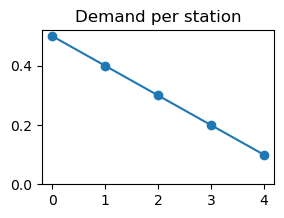

In [2]:
scenario = 'few_stations'

if scenario == 'few_stations':
    n_stations = 5
    n_levels = 5 # How many levels of demand are there
    default_demand = 0.5 # Order frequency, betweeen 0 and 1. 
                          # If too low, many runs are wasted. If too high, it's no longer a poisson-like process.
    demand_levels = np.arange(n_levels, 0, -1)/n_levels * default_demand
    n_cars = 20
elif scenario == 'suburbs': # Center and suburbs
    n_stations = 10
    n_levels = 10
    demand_levels = np.array(list(np.arange(0.5, 0.25, -0.05)) + list(np.arange(0.3, 0.2, -0.02)/10))    
    n_cars = 5
else:
    raise ValueError("Unknown scenario")
       
n_steps_preparation = 50000 # For how many steps stats are NOT collected
n_steps_per_experiment = 2000
n_experiments = 100

demand = (list(demand_levels)*int(np.ceil(n_stations / n_levels)))[:n_stations] # Circular sampling, if needed

plt.figure(figsize=(3, 2)) # Visualize demand, to be sure
plt.plot(demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");
#print("Demand values to be used:", [np.round(x, 3) for x in demand])

In [10]:
# Main loop

def run_model(rentals_per_relocation=50, n_experiments=n_experiments, n_cars=n_cars):
    # Set rentals_per_relocation to 0 to not have any relocations
    
    n_steps =  n_steps_per_experiment*n_experiments + n_steps_preparation
    
    cm1 = np.zeros(shape=(n_experiments, n_stations))
    average_cars = np.zeros(shape=(n_experiments, n_stations))
    total_attempts = np.zeros(shape=(n_experiments, n_stations))
    total_rentals = np.zeros(shape=(n_experiments, n_stations))
    total_relos = np.zeros(shape=(n_experiments, n_stations))

    state_history = np.zeros(shape=(n_steps_per_experiment, n_stations)) # Will only remember one run

    state = np.array([n_cars] + [0]*(n_stations-1)) # Case of all cars injected in the hot tile
    #state = np.array([n_cars // n_stations]*n_stations) # Case of cars being distributed uniformly
    state[0] = n_cars - state[1:].sum() # Only needed for uniform cas (to make sure n_cars is right)
    # print("Initial cars distribution across stations:", state)

    for i_step in range(n_steps):
        attempts = (np.random.uniform(size=n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(
            n_stations, size=n_stations, p=demand/sum(demand)) # Where a car would go if ordered
        # The formula above assumes that ultimately in and out flows for every station are balanced, so if 
        # few people depart from the station (low demand), it will also be unlikely to become a destination
        # (that's why normalized demand is used as a probability parameter for random.choice)
        
        if (i_step >= n_steps_preparation) & ((i_step - n_steps_preparation) % n_steps_per_experiment == 0):
            i_experiment = (i_step - n_steps_preparation) // n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals

        if (rentals_per_relocation != 0) and (i_step % rentals_per_relocation == 0): # Relocations
            demand_per_car = demand/state.clip(1,None)
            start_relo = np.where(
                (demand_per_car == demand_per_car[state>0].min()) & (state > 0)
            )[0][0]
            end_relo = np.argmax(demand/(1+state.clip(1, None)))
            state[start_relo] -= 1
            state[end_relo] += 1
            relo_happened = True
        else:
            relo_happened = False

        if i_step > n_steps_preparation: # Collect stats
            cm1[i_experiment, :] += (departures + arrivals)/2/n_steps_per_experiment
            # We divide it by 2 for the sum across all cm1 to be true (not double-counted)
            average_cars[i_experiment, :] += state/n_steps_per_experiment
            total_attempts[i_experiment, :] += attempts*1            
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

            if (n_steps - i_step) < n_steps_per_experiment: # Last run            
                state_history[(i_step - n_steps_preparation) % n_steps_per_experiment, :] = state
                
    return cm1, average_cars, total_attempts, total_rentals, total_relos, state_history
        
    
# Immediate outputs (debugging)
cm1, average_cars, total_attempts, total_rentals, total_relos, state_history = \
    run_model(rentals_per_relocation=20)
average_cars.shape

....................................................................................................

(100, 5)

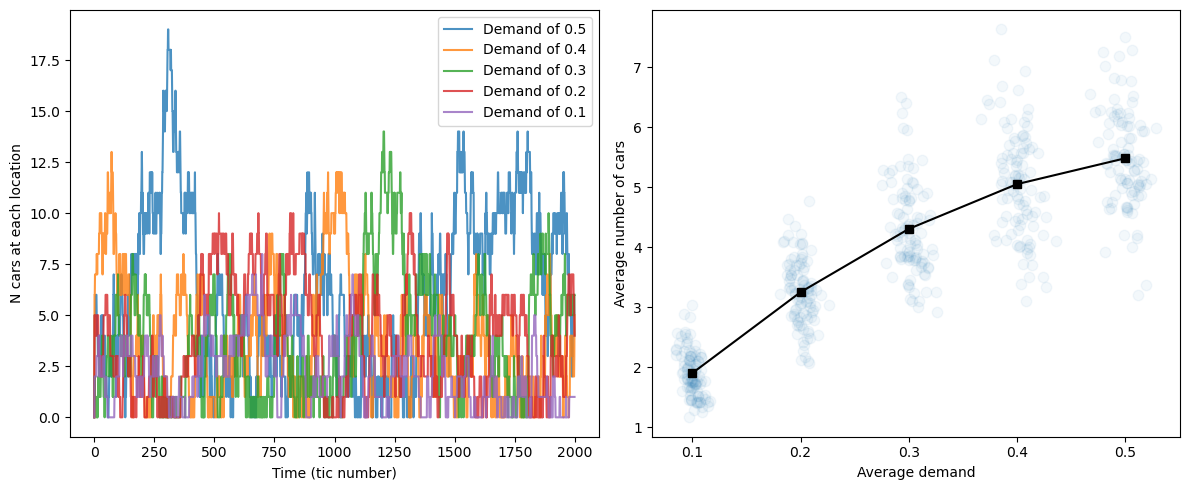

In [11]:
# Save figure

plt.figure(figsize=(12, 5), facecolor='white')

# The tracks from one (last) experiment
plt.subplot(121)
plt.plot(state_history, alpha=0.8);
if n_stations <= 5:
    plt.legend(labels=[f"Demand of {d}" for d in demand]);
plt.xlabel("Time (tic number)")
plt.ylabel("N cars at each location");

# Combined results
plt.subplot(122)
#plt.plot(list(demand)*n_experiments, history.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(total_attempts.flatten()/n_steps_per_experiment, 
         average_cars.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(demand, average_cars.mean(axis=0), 'ks-')
plt.xlabel("Average demand")
plt.ylabel("Average number of cars");

plt.tight_layout()
plt.savefig(f"../figures/02relos_02stations_01ncars_{scenario}.svg", dpi=300)

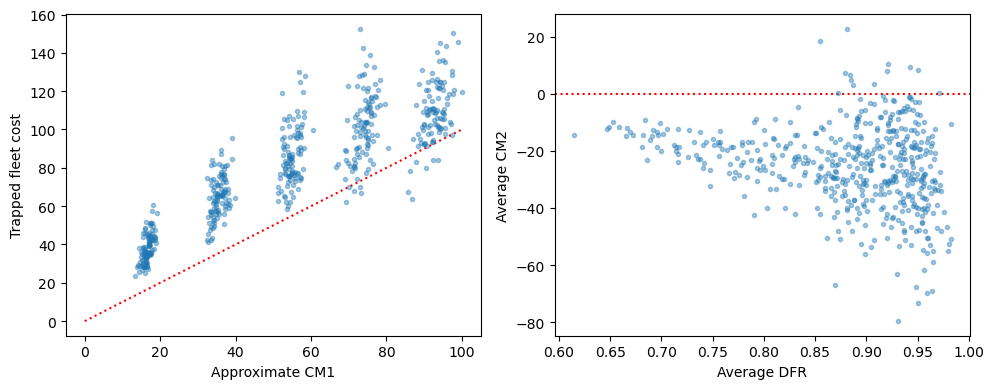

In [12]:
# Business measures
cm1_per_tick = 20/max(demand_levels)*5 # Assuming 20 trips/day from the hottest zone, and 5 €/trip CM1
cm2_per_car = 20

plt.figure(figsize=(10,4));
plt.subplot(121)
x = cm1.flatten()*cm1_per_tick
plt.plot([0, max(x)], [0, max(x)], 'r:')
plt.plot(x, average_cars.flatten()*cm2_per_car, '.', alpha=0.4);
plt.xlabel("Approximate CM1")
plt.ylabel("Trapped fleet cost");

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
plt.plot(total_rentals.flatten()/total_attempts.flatten().clip(1,None), 
         cm1.flatten()*cm1_per_tick - average_cars.flatten()*cm2_per_car, '.', alpha=0.4);
plt.xlabel("Average DFR")
plt.ylabel("Average CM2");

plt.tight_layout()

plt.savefig(f"../figures/02relos_02stations_02financials_{scenario}.svg", dpi=300)

# Optimal number of relocations

In [13]:
# Optimal number of relocations
# (Make sure to load a correct scenario before running this one)

relo_frequencies = [1, 10, 20, 35, 50, 75, 100, 150, 200]
relocation_periods = [int(n_steps_per_experiment/freq) for freq in relo_frequencies]
print(relocation_periods)

cm1_per_trip = 5
relo_cost = 20
n_experiments = 100

cm1_memory = np.zeros(shape=(n_experiments, len(relocation_periods)))

for i, rpr in enumerate(relocation_periods):
    cm1, average_cars, total_attempts, total_rentals, total_relos, history = \
        run_model(rentals_per_relocation=rpr, n_experiments=n_experiments)    
    
    # Calculate full CM1
    cm1_memory[:, i] = (
        total_rentals.sum(axis=1)/n_steps_per_experiment * cm1_per_trip # Sum accross stations,
        - total_relos.sum(axis=1)/n_steps_per_experiment * relo_cost    # ... but not across experiments
    )
    print() # New line
    
cm1_memory.shape

[2000, 200, 100, 57, 40, 26, 20, 13, 10]
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................


(100, 9)

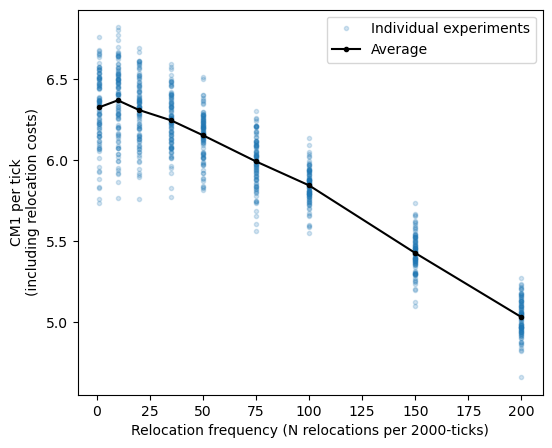

In [15]:
# Save figure
plt.figure(figsize=(6,5))
plt.plot(list(relo_frequencies)*n_experiments, cm1_memory.flatten(), '.', color='tab:blue', alpha=0.2,
         label="Individual experiments");
plt.plot(relo_frequencies, cm1_memory.mean(axis=0), 'k.-', label='Average');
plt.xlabel(f"Relocation frequency (N relocations per {n_steps_per_experiment}-ticks)")
plt.ylabel("CM1 per tick\n(including relocation costs)");
#plt.title(f"Scenario: {scenario}")
plt.legend(loc="upper right")

plt.savefig(f"../figures/02relos_02stations_03optimal_number_{scenario}.svg", dpi=300)